In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../data/raw/datafile (1).csv")

In [12]:
df.columns = [
    "Crop",
    "State",
    "Cultivation_Cost_A2_FL",
    "Cultivation_Cost_C2",
    "Production_Cost",
    "Yield"
]

In [13]:
df.head()

,Crop,State,Cultivation_Cost_A2_FL,Cultivation_Cost_C2,Production_Cost,Yield
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [15]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (49, 6)

Columns:
Index(['Crop', 'State', 'Cultivation_Cost_A2_FL', 'Cultivation_Cost_C2',
       'Production_Cost', 'Yield'],
      dtype='str')

Missing Values:
Crop                      0
State                     0
Cultivation_Cost_A2_FL    0
Cultivation_Cost_C2       0
Production_Cost           0
Yield                     0
dtype: int64

Duplicate Rows: 0


In [16]:
df.describe()

,Cultivation_Cost_A2_FL,Cultivation_Cost_C2,Production_Cost,Yield
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


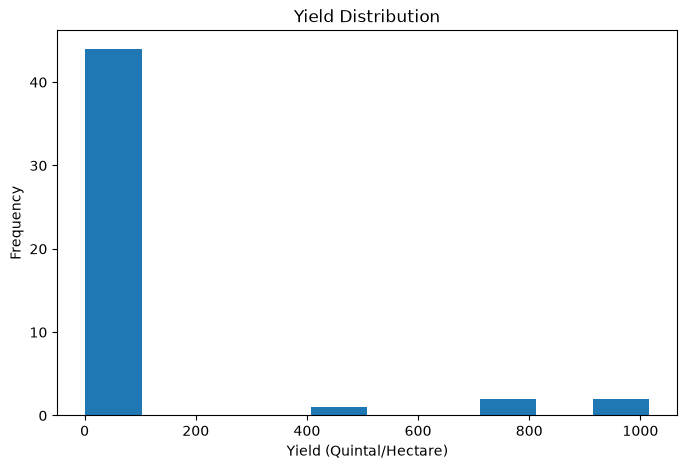

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=10)

plt.title("Yield Distribution")
plt.xlabel("Yield (Quintal/Hectare)")
plt.ylabel("Frequency")

plt.show()

In [18]:
top_yield = df.sort_values(by="Yield", ascending=False)

top_yield.head(10)[["Crop", "State", "Yield"]]

,Crop,State,Yield
44,SUGARCANE,Tamil Nadu,1015.45
41,SUGARCANE,Karnataka,986.21
42,SUGARCANE,Andhra Pradesh,757.92
43,SUGARCANE,Maharashtra,744.01
40,SUGARCANE,Uttar Pradesh,448.89
33,PADDY,Punjab,67.41
34,PADDY,Andhra Pradesh,56.00
20,MAIZE,Bihar,42.95
24,MAIZE,Andhra Pradesh,42.68
46,WHEAT,Punjab,39.83


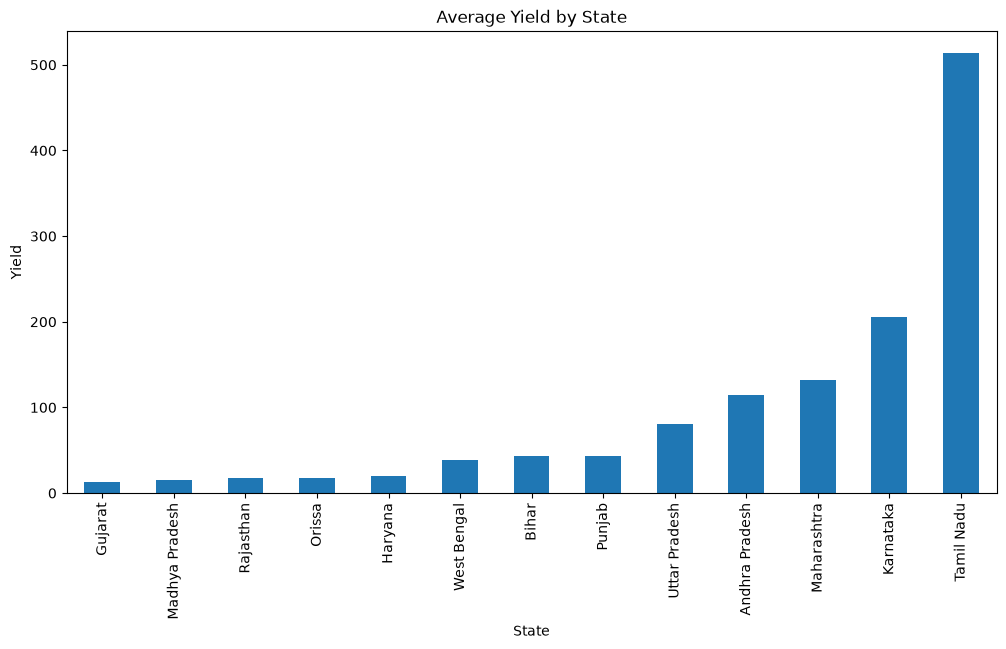

In [19]:
avg_state = df.groupby("State")["Yield"].mean()

avg_state = avg_state.sort_values()

plt.figure(figsize=(12,6))

avg_state.plot(kind="bar")

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Yield")

plt.xticks(rotation=90)

plt.show()

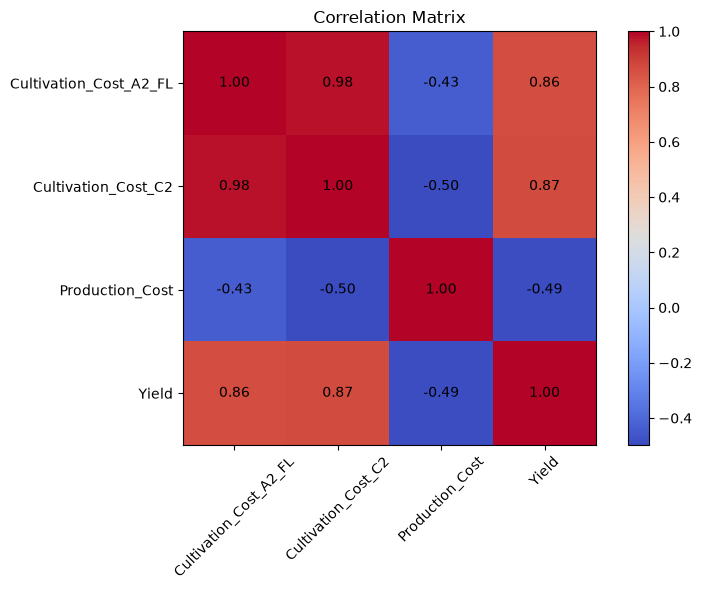

In [20]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j,
                 i,
                 f"{correlation.iloc[i, j]:.2f}",
                 ha="center",
                 va="center",
                 fontsize=10)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

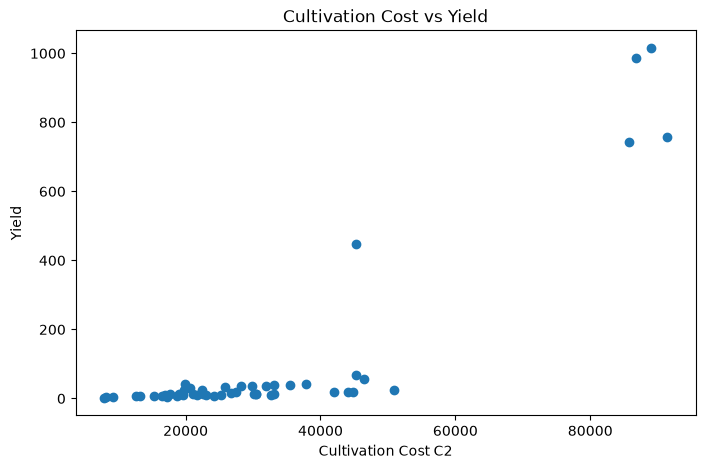

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Cultivation_Cost_C2"],
            df["Yield"])

plt.xlabel("Cultivation Cost C2")
plt.ylabel("Yield")
plt.title("Cultivation Cost vs Yield")

plt.show()

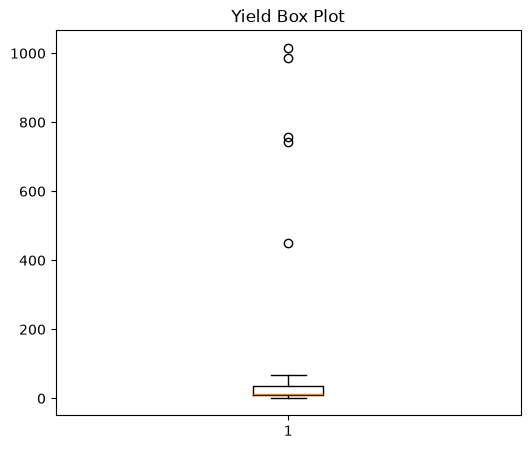

In [22]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Yield"])

plt.title("Yield Box Plot")

plt.show()

In [23]:
df.select_dtypes(include="number").corr()

,Cultivation_Cost_A2_FL,Cultivation_Cost_C2,Production_Cost,Yield
Cultivation_Cost_A2_FL,1.000000,0.981225,-0.434422,0.863400
Cultivation_Cost_C2,0.981225,1.000000,-0.497092,0.866424
Production_Cost,-0.434422,-0.497092,1.000000,-0.487272
Yield,0.863400,0.866424,-0.487272,1.000000
